# Campaign Sensor Calibration

This notebook trains and stores the project spectral calibration model for any
dataset under `data/campaigns/<campaign_label>`.

System boundary:
- `measurement_calibration.sensor_ranking` loads campaign CSV files and aligns realizations.
- `measurement_calibration.campaign_calibration` adapts the aligned campaign into the generic calibration contract and persists the artifact.
- `measurement_calibration.spectral_calibration` fits the latent-variable gain and additive-noise model.

Side effect: executing the training cell writes a model artifact under
`models/campaign_spectral_calibration/<campaign_label>/`.


In [1]:
from __future__ import annotations

import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the notebook launch directory."""

    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "measurement_calibration").exists() and (
            candidate / "data"
        ).exists():
            return candidate
    raise RuntimeError(
        "Could not locate the repository root from the current notebook session"
    )


def power_linear_to_plot_db(
    power_linear: np.ndarray,
    floor_power: float = 1.0e-18,
) -> np.ndarray:
    """Convert linear power to dB with a plotting floor below the solver floor."""

    return 10.0 * np.log10(
        np.clip(np.asarray(power_linear, dtype=np.float64), floor_power, None)
    )


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import measurement_calibration.artifacts as artifacts_module  # noqa: E402
import measurement_calibration.campaign_calibration as campaign_calibration_module  # noqa: E402
import measurement_calibration.sensor_ranking as sensor_ranking_module  # noqa: E402
import measurement_calibration.spectral_calibration as spectral_calibration_module  # noqa: E402

artifacts_module = importlib.reload(artifacts_module)
campaign_calibration_module = importlib.reload(campaign_calibration_module)
sensor_ranking_module = importlib.reload(sensor_ranking_module)
spectral_calibration_module = importlib.reload(spectral_calibration_module)

build_campaign_calibration_output_dir = (
    campaign_calibration_module.build_campaign_calibration_output_dir
)
build_campaign_sensor_validation_rows = (
    campaign_calibration_module.build_campaign_sensor_validation_rows
)
fit_and_save_campaign_calibration_model = (
    campaign_calibration_module.fit_and_save_campaign_calibration_model
)
prepare_campaign_calibration_dataset = (
    campaign_calibration_module.prepare_campaign_calibration_dataset
)
load_spectral_calibration_artifact = (
    artifacts_module.load_spectral_calibration_artifact
)
build_campaign_alignment_rows = (
    sensor_ranking_module.build_campaign_alignment_rows
)
build_distribution_summary_rows = (
    sensor_ranking_module.build_distribution_summary_rows
)
build_sensor_ranking_rows = sensor_ranking_module.build_sensor_ranking_rows
apply_deployed_calibration = (
    spectral_calibration_module.apply_deployed_calibration
)
compute_network_consensus = (
    spectral_calibration_module.compute_network_consensus
)
power_linear_to_db = spectral_calibration_module.power_linear_to_db

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

CAMPAIGNS_ROOT = REPO_ROOT / "data" / "campaigns"
MODELS_ROOT = REPO_ROOT / "models" / "campaign_spectral_calibration"
TRAINING_CAMPAIGN_LABEL = "MeasurementCalibration"
EXCLUDED_SENSOR_IDS: tuple[str, ...] = ()
RANKING_HISTOGRAM_BINS = 50
DISTRIBUTION_HISTOGRAM_BINS = 300
ALIGNMENT_TOLERANCE_MS: int | None = None
TEST_FRACTION = 0.2
SPLIT_STRATEGY = "tail"
FIT_CONFIG = {
    "n_iterations": 6,
    "lambda_gain_smooth": 120.0,
    "lambda_noise_smooth": 180.0,
    "lambda_gain_reference": 4.0,
    "lambda_noise_reference": 60.0,
    "lambda_reliable_anchor": 1.0,
    "reliable_weight_boost": 1.10,
    "low_information_threshold_ratio": 0.10,
    "low_information_weight": 0.05,
}
PLOT_STRIDE_TARGET = 1024
SELECTED_TEST_RECORD_INDEX = 0


## Load And Diagnose The Campaign

The preparation step is pure orchestration around three deterministic stages:
sensor loading, timestamp alignment, and campaign-specific ranking diagnostics.


In [2]:
preparation = prepare_campaign_calibration_dataset(
    campaign_label=TRAINING_CAMPAIGN_LABEL,
    campaigns_root=CAMPAIGNS_ROOT,
    excluded_sensor_ids=EXCLUDED_SENSOR_IDS,
    ranking_histogram_bins=RANKING_HISTOGRAM_BINS,
    distribution_histogram_bins=DISTRIBUTION_HISTOGRAM_BINS,
    alignment_tolerance_ms=ALIGNMENT_TOLERANCE_MS,
)
dataset = preparation.calibration_dataset
output_dir = build_campaign_calibration_output_dir(
    TRAINING_CAMPAIGN_LABEL,
    models_root=MODELS_ROOT,
)

preparation_summary = pd.DataFrame(
    {
        "metric": [
            "campaign_label",
            "campaign_dir",
            "retained_sensor_count",
            "aligned_record_count",
            "frequency_bin_count",
            "reliable_sensor_id",
            "alignment_anchor_sensor_id",
            "distribution_outlier_sensor_ids",
            "excluded_sensor_ids",
            "model_output_dir",
        ],
        "value": [
            preparation.campaign_label,
            str(preparation.campaign_dir),
            len(dataset.sensor_ids),
            preparation.alignment_diagnostics.aligned_record_count,
            dataset.frequency_hz.size,
            preparation.reliable_sensor_id,
            preparation.alignment_diagnostics.anchor_sensor_id,
            ", ".join(preparation.distribution_outlier_sensor_ids) or "<none>",
            ", ".join(preparation.excluded_sensor_ids) or "<none>",
            str(output_dir),
        ],
    }
)
alignment_table = (
    pd.DataFrame(build_campaign_alignment_rows(preparation.alignment_diagnostics))
    .sort_values("sensor_id")
    .reset_index(drop=True)
)
ranking_table = (
    pd.DataFrame(build_sensor_ranking_rows(preparation.ranking_result))
    .sort_values("rank")
    .reset_index(drop=True)
)
distribution_table = (
    pd.DataFrame(
        build_distribution_summary_rows(preparation.distribution_diagnostics)
    )
    .sort_values("rank")
    .reset_index(drop=True)
)

display(preparation_summary)
display(alignment_table)
display(ranking_table)
display(distribution_table)
print(
    "Observation tensor shape: "
    f"{dataset.observations_power.shape} = (sensors, experiments, frequencies)"
)
print(
    f"Selected common band: {dataset.selected_band_hz[0] / 1e6:.1f}-"
    f"{dataset.selected_band_hz[1] / 1e6:.1f} MHz"
)


,metric,value
0,campaign_label,MeasurementCalibration
1,campaign_dir,/home/marti/Code/MeasurementCalibration/data/c...
2,retained_sensor_count,5
3,aligned_record_count,30
4,frequency_bin_count,4096
5,reliable_sensor_id,Node2
6,alignment_anchor_sensor_id,Node1
7,distribution_outlier_sensor_ids,"Node9, Node1"
8,excluded_sensor_ids,<none>
9,model_output_dir,/home/marti/Code/MeasurementCalibration/models...


,campaign_label,sensor_id,is_anchor_sensor,source_records,aligned_records,dropped_records,retained_fraction,alignment_tolerance_ms,mean_record_time_spread_ms,max_record_time_spread_ms
0,MeasurementCalibration,Node1,True,30,30,0,1.0000,5000,1677.3667,2436.0000
1,MeasurementCalibration,Node2,False,30,30,0,1.0000,5000,1677.3667,2436.0000
2,MeasurementCalibration,Node3,False,30,30,0,1.0000,5000,1677.3667,2436.0000
3,MeasurementCalibration,Node5,False,30,30,0,1.0000,5000,1677.3667,2436.0000
4,MeasurementCalibration,Node9,False,30,30,0,1.0000,5000,1677.3667,2436.0000


,rank,sensor_id,mean_score,mean_correlation,score_std,mean_noise_floor_db,records
0,1,Node2,3.4789,0.8697,0.0128,-24.5965,30
1,2,Node1,3.4752,0.8688,0.0163,-25.9273,30
2,3,Node3,3.3086,0.8272,0.0220,-24.4683,30
3,4,Node5,3.3004,0.8251,0.0215,-23.8594,30
4,5,Node9,3.0208,0.7552,0.0268,-23.1085,30


,rank,sensor_id,distribution_similarity,normalized_similarity,mean_psd_db,std_psd_db,min_psd_db,max_psd_db,value_count,is_low_similarity_outlier
0,1,Node3,3.0418,0.7604,-20.3144,4.6330,-25.5265,8.0489,122880,False
1,2,Node2,2.9696,0.7424,-20.4865,4.6488,-25.4693,11.0261,122880,False
2,3,Node5,2.8722,0.7181,-20.2529,4.3981,-24.7755,8.6344,122880,False
3,4,Node9,2.3396,0.5849,-19.6590,4.3923,-23.8336,6.4587,122880,True
4,5,Node1,2.2861,0.5715,-20.9260,5.0526,-26.7049,8.5937,122880,True


Observation tensor shape: (5, 30, 4096) = (sensors, experiments, frequencies)
Selected common band: 88.0-108.0 MHz


## Fit And Store The Model

The fitted artifact is written under `models/` so later notebooks can reload the
exact same parameters without retraining.


In [3]:
fit_result = fit_and_save_campaign_calibration_model(
    preparation=preparation,
    output_dir=output_dir,
    fit_config=FIT_CONFIG,
    test_fraction=TEST_FRACTION,
    split_strategy=SPLIT_STRATEGY,
)
artifact = load_spectral_calibration_artifact(output_dir)
result = artifact.result

fit_summary = pd.DataFrame(
    {
        "metric": [
            "train_experiments",
            "test_experiments",
            "reliable_sensor_id",
            "alignment_anchor_sensor_id",
            "fit_duration_s",
            "objective_start",
            "objective_end",
            "raw_mean_sensor_std_db",
            "corrected_mean_sensor_std_db",
            "corrected_to_raw_dispersion_ratio",
            "global_low_information_fraction",
            "sensor_low_information_fraction",
            "gain_cap_fraction",
            "noise_zero_fraction",
        ],
        "value": [
            int(result.train_indices.size),
            int(result.test_indices.size),
            preparation.reliable_sensor_id,
            preparation.alignment_diagnostics.anchor_sensor_id,
            fit_result.fit_duration_s,
            float(result.objective_history[0]),
            float(result.objective_history[-1]),
            fit_result.validation.raw_mean_sensor_std_db,
            fit_result.validation.corrected_mean_sensor_std_db,
            fit_result.validation.corrected_to_raw_dispersion_ratio,
            float(np.mean(result.frequency_low_information_mask)),
            float(np.mean(result.low_information_mask)),
            float(np.mean(result.gain_at_correction_bound_mask)),
            float(np.mean(result.noise_zero_mask)),
        ],
    }
)
validation_table = (
    pd.DataFrame(build_campaign_sensor_validation_rows(fit_result.validation))
    .sort_values("rmse_to_consensus_db")
    .reset_index(drop=True)
)
artifact_paths = pd.DataFrame(
    {
        "artifact_component": [
            "output_dir",
            "manifest_path",
            "parameters_path",
            "sensor_summary_path",
        ],
        "path": [
            str(artifact.output_dir),
            str(artifact.manifest_path),
            str(artifact.parameters_path),
            str(artifact.sensor_summary_path),
        ],
    }
)

display(fit_summary)
display(validation_table)
display(artifact_paths)
print(f"Stored model artifact in: {artifact.output_dir}")


,metric,value
0,train_experiments,24
1,test_experiments,6
2,reliable_sensor_id,Node2
3,alignment_anchor_sensor_id,Node1
4,fit_duration_s,0.5669
5,objective_start,-3677085.5440
6,objective_end,-4025218.5761
7,raw_mean_sensor_std_db,1.3058
8,corrected_mean_sensor_std_db,0.3961
9,corrected_to_raw_dispersion_ratio,0.3034


,sensor_id,mean_bias_to_consensus_db,rmse_to_consensus_db,invalid_corrected_fraction,median_information_weight,low_information_fraction,gain_cap_fraction,alignment_median_error_ms
0,Node1,-0.1117,0.4580,0.0000,0.7118,0.4182,0.0000,101.0000
1,Node2,0.1815,0.8146,0.0000,0.8792,0.3591,0.0000,324.5000
2,Node5,0.0588,0.8682,0.0000,0.6691,0.4453,0.0000,971.5000
3,Node3,0.0926,0.9464,0.0000,0.8208,0.3789,0.0000,142.5000
4,Node9,0.0257,1.4449,0.0000,0.6609,0.4587,0.0000,931.0000


,artifact_component,path
0,output_dir,/home/marti/Code/MeasurementCalibration/models...
1,manifest_path,/home/marti/Code/MeasurementCalibration/models...
2,parameters_path,/home/marti/Code/MeasurementCalibration/models...
3,sensor_summary_path,/home/marti/Code/MeasurementCalibration/models...


Stored model artifact in: /home/marti/Code/MeasurementCalibration/models/campaign_spectral_calibration/MeasurementCalibration


## Hold-Out Validation

These plots use the stored parameters exactly as they would be deployed: raw power,
calibrated power, and a leave-one-network consensus built from the corrected spectra.


Visualized hold-out record index: 0 of 5
Masked invalid corrected fraction: 0.00000


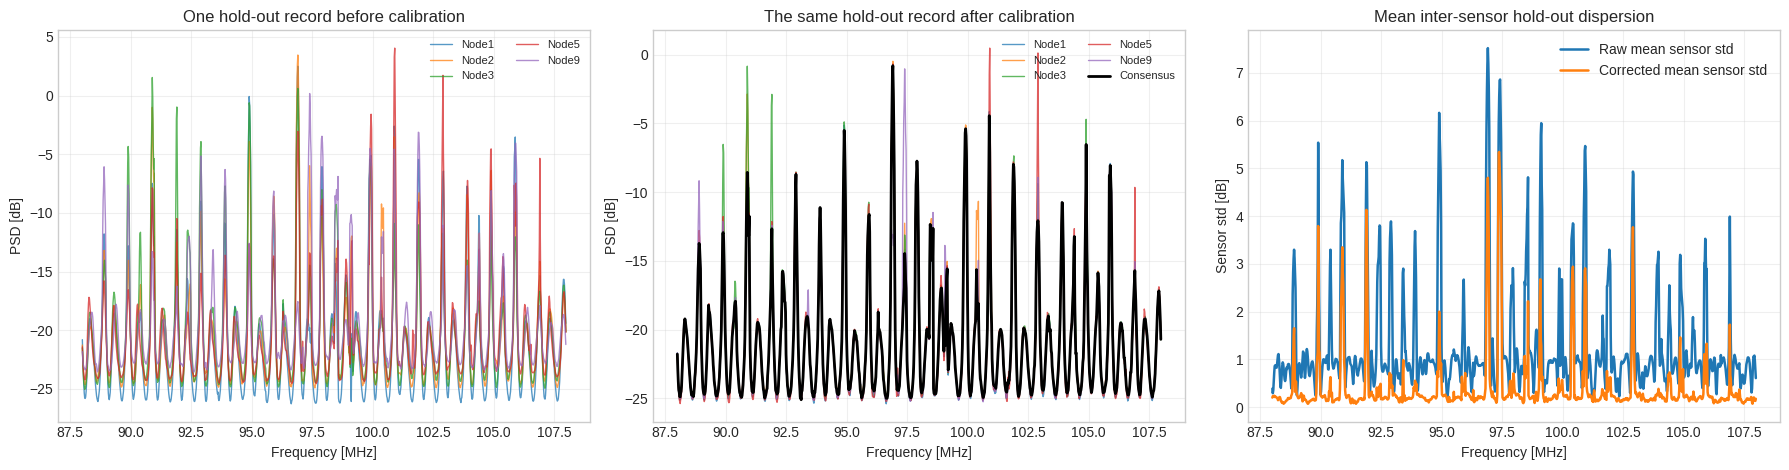

In [4]:
raw_test_power = dataset.observations_power[:, result.test_indices, :]
corrected_test_power = apply_deployed_calibration(
    observations_power=raw_test_power,
    gain_power=result.gain_power,
    additive_noise_power=result.additive_noise_power,
)
invalid_corrected_mask = (
    raw_test_power <= result.additive_noise_power[:, np.newaxis, :]
)
consensus_test_power = compute_network_consensus(
    corrected_power=corrected_test_power,
    residual_variance_power2=result.residual_variance_power2,
    valid_mask=~invalid_corrected_mask,
)

raw_test_db = power_linear_to_db(raw_test_power)
corrected_test_db = power_linear_to_db(corrected_test_power)
corrected_test_plot_db = np.where(
    invalid_corrected_mask,
    np.nan,
    corrected_test_db,
)
consensus_test_db = power_linear_to_db(consensus_test_power)
raw_dispersion_db = np.std(raw_test_db, axis=0)
corrected_plot_dispersion_db = np.nanstd(corrected_test_plot_db, axis=0)

plot_stride = max(1, dataset.frequency_hz.size // PLOT_STRIDE_TARGET)
freq_mhz = dataset.frequency_hz[::plot_stride] / 1e6
selected_test_record_index = min(
    SELECTED_TEST_RECORD_INDEX,
    raw_test_db.shape[1] - 1,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for sensor_index, sensor_id in enumerate(result.sensor_ids):
    axes[0].plot(
        freq_mhz,
        raw_test_db[sensor_index, selected_test_record_index, ::plot_stride],
        linewidth=1.0,
        alpha=0.75,
        label=sensor_id,
    )
    axes[1].plot(
        freq_mhz,
        corrected_test_plot_db[
            sensor_index,
            selected_test_record_index,
            ::plot_stride,
        ],
        linewidth=1.0,
        alpha=0.75,
        label=sensor_id,
    )
axes[1].plot(
    freq_mhz,
    consensus_test_db[selected_test_record_index, ::plot_stride],
    color="black",
    linewidth=2.0,
    label="Consensus",
)
axes[0].set_title("One hold-out record before calibration")
axes[1].set_title("The same hold-out record after calibration")
for axis in axes[:2]:
    axis.set_xlabel("Frequency [MHz]")
    axis.set_ylabel("PSD [dB]")
    axis.grid(True, alpha=0.30)
axes[0].legend(fontsize=8, ncol=2)
axes[1].legend(fontsize=8, ncol=2)

axes[2].plot(
    freq_mhz,
    np.mean(raw_dispersion_db, axis=0)[::plot_stride],
    linewidth=1.8,
    label="Raw mean sensor std",
)
axes[2].plot(
    freq_mhz,
    np.nanmean(corrected_plot_dispersion_db, axis=0)[::plot_stride],
    linewidth=1.8,
    label="Corrected mean sensor std",
)
axes[2].set_title("Mean inter-sensor hold-out dispersion")
axes[2].set_xlabel("Frequency [MHz]")
axes[2].set_ylabel("Sensor std [dB]")
axes[2].grid(True, alpha=0.30)
axes[2].legend()
plt.tight_layout()

print(
    f"Visualized hold-out record index: {selected_test_record_index} of "
    f"{raw_test_db.shape[1] - 1}"
)
print(
    f"Masked invalid corrected fraction: {np.mean(invalid_corrected_mask):.5f}"
)


## Learned Sensor Parameters

The gain and additive-noise curves are the deployable model parameters. The objective
history is shown to confirm the alternating solver stabilized over the configured passes.


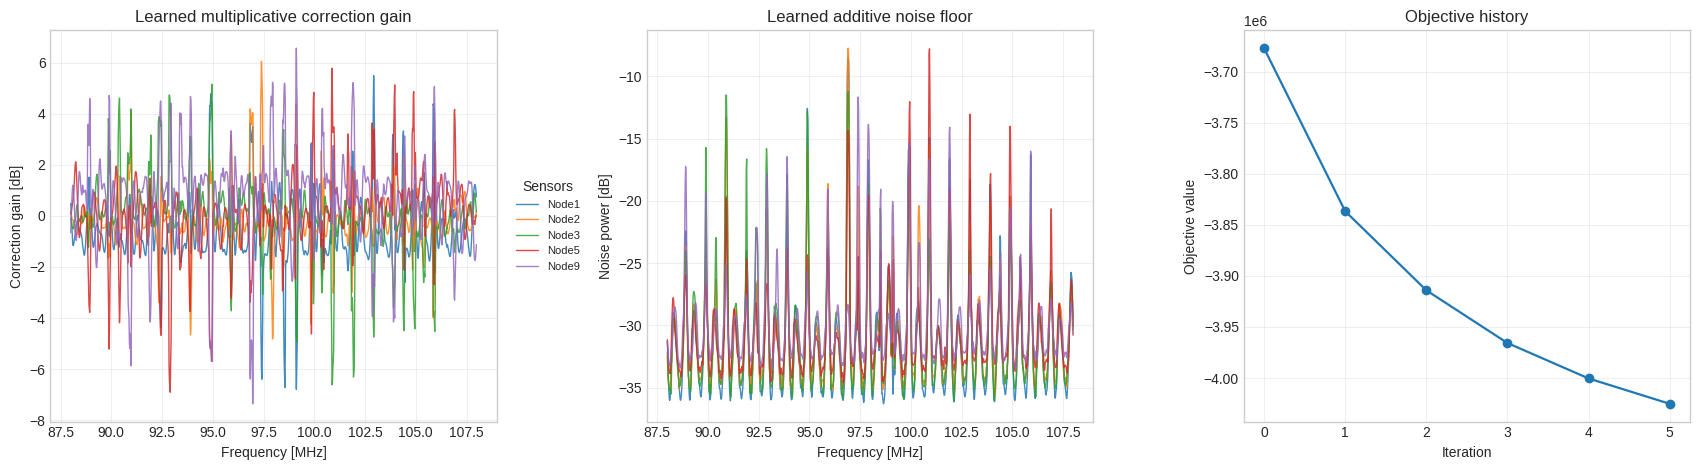

In [5]:
correction_gain_db = power_linear_to_plot_db(result.correction_gain_power)
additive_noise_db = power_linear_to_plot_db(result.additive_noise_power)

fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
for sensor_index, sensor_id in enumerate(result.sensor_ids):
    axes[0].plot(
        freq_mhz,
        correction_gain_db[sensor_index, ::plot_stride],
        linewidth=1.0,
        alpha=0.85,
        label=sensor_id,
    )
    axes[1].plot(
        freq_mhz,
        additive_noise_db[sensor_index, ::plot_stride],
        linewidth=1.0,
        alpha=0.85,
    )

axes[0].set_title("Learned multiplicative correction gain")
axes[0].set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("Correction gain [dB]")
axes[0].grid(True, alpha=0.30)
axes[0].legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8,
    title="Sensors",
)

axes[1].set_title("Learned additive noise floor")
axes[1].set_xlabel("Frequency [MHz]")
axes[1].set_ylabel("Noise power [dB]")
axes[1].grid(True, alpha=0.30)

axes[2].plot(
    np.arange(result.objective_history.size),
    result.objective_history,
    marker="o",
    linewidth=1.6,
)
axes[2].set_title("Objective history")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Objective value")
axes[2].grid(True, alpha=0.30)

plt.tight_layout(rect=(0.0, 0.0, 0.90, 1.0))
